In [14]:
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

In [15]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [16]:

class State(TypedDict):
    topic: set
    code: str
    improved_code : str
    final_code : str
    

In [17]:
# Node
def gen_code(state: State):
    msg = llm.invoke(f"""write a python code to implement {state['topic']} /
                     Do NOT include:
                    - Markdown formatting
                    - Headings
                    - Explanations
                    - Comments unless necessary
                    - Bold text
                    - Code blocks
                    - ```python fences. 
                    - Return ONLY raw Python code.
                    """)
    ### msg = llm.invoke(f"Write a short joke about 
    return {"code": msg.content}    


In [18]:
def optimise_code(state: State):
    """Second LLM call to optimize the code"""

    msg = llm.invoke(f"""optimize the code {state['code']} based on the topic {state['topic']}""")
    return {"improved_code": msg.content}

In [19]:
def keep_code_and_comments(text: str) -> str:
    clean_lines = []
    for line in text.splitlines():
        stripped = line.strip()
        # keep if line starts with comment (#) or looks like Python code
        if stripped.startswith("#") or stripped:
            if stripped.startswith("```"):
                continue
            clean_lines.append(line)
    return "\n".join(clean_lines)


In [20]:
def final_code(state: State):
    """Third LLM call for final code which will include documentation to the generated code"""
    code = state.get("improved_code") or state.get("code")


    msg = llm.invoke(f"""Along with the raw code include its explaination as documentation {code} 
                     - Place the docummention as comments 
                     - include only raw code and documentation as comment in the code
                     - without ```python fences.
                     Do NOT include:
                    - Markdown formatting
                    - Headings
                    - Bold text
                    - Code blocks 
                    - Return ONLY raw Python code and documentation as comment. """)
    cleaned = keep_code_and_comments(msg.content)
    
    return {"final_code": cleaned}

In [21]:
import black
from datetime import datetime

def save_file(state:State):
    

    #formatted = black.format_str(state['final_code'], mode=black.Mode())
    safe_topic = state['topic'].replace(" ", "_").lower()
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{safe_topic[:15]}_{timestamp}"

    with open(f"{filename}.py", "w") as f:
        f.write(state['final_code'])


In [22]:
def check_punchline(state: State):
    raw_code = state["code"]

    # 1. Length check
    if len(raw_code.splitlines()) > 20:
        return "Fail"

    # 2. Redundant nested loops
    if raw_code.count("for ") >= 2:
        return "Fail"

    # 3. Bad patterns
    bad_patterns = ["range(len(", "while True", "time.sleep", "global "]
    if any(p in raw_code for p in bad_patterns):
        return "Fail"

    # 4. AST complexity: detect too many branches
    import ast
    tree = ast.parse(raw_code)
    branches = sum(isinstance(n, (ast.If, ast.For, ast.While)) for n in ast.walk(tree))
    if branches > 8:
        return "Fail"

    # If none triggered → code is OK

    return "Pass"


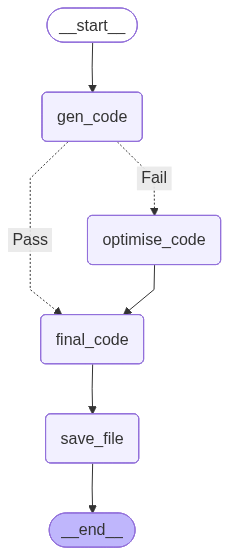

In [23]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("gen_code", gen_code)
workflow.add_node("optimise_code", optimise_code)
workflow.add_node("final_code", final_code)
workflow.add_node("save_file", save_file)


# Add edges to connect nodes
workflow.add_edge(START, "gen_code")
workflow.add_edge("optimise_code", "final_code")
workflow.add_conditional_edges("gen_code",check_punchline,{"Fail":"optimise_code","Pass":"final_code"})
workflow.add_edge("final_code", "save_file")
workflow.add_edge( "save_file", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))



In [30]:
# Invoke
state = chain.invoke( {'topic': 'find area of circle'})

In [28]:
state

{'topic': 'generate 5 fibonacci number',
 'code': 'def fibonacci(n):\n    fib_sequence = [0, 1]\n    while len(fib_sequence) < n:\n        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])\n    return fib_sequence\n\nprint(fibonacci(5))',
 'final_code': "# This function generates a Fibonacci sequence of 'n' numbers.\n# The Fibonacci sequence is a series of numbers in which each number is the sum of the two preceding ones, usually starting with 0 and 1.\ndef fibonacci(n):\n    # Initialize a list to store the Fibonacci sequence with the first two numbers.\n    fib_sequence = [0, 1]\n    # Continue generating numbers until the sequence has 'n' numbers.\n    while len(fib_sequence) < n:\n        # Calculate the next number as the sum of the last two numbers in the sequence.\n        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])\n    # Return the generated Fibonacci sequence.\n    return fib_sequence\n# Test the function by generating a Fibonacci sequence of 5 numbers.\np

In [26]:
print(state['final_code'])

# This function generates a Fibonacci sequence of 'n' numbers.
# The Fibonacci sequence is a series of numbers where a number is the sum of the two preceding ones, usually starting with 0 and 1.
def fibonacci(n):
    # Initialize a list to store the Fibonacci sequence with the first two numbers.
    fib_sequence = [0, 1]
    # Continue generating numbers until the sequence has 'n' numbers.
    while len(fib_sequence) < n:
        # Append the sum of the last two numbers in the sequence to the sequence.
        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])
    # Return the generated Fibonacci sequence.
    return fib_sequence
# Test the function by generating a Fibonacci sequence of 5 numbers.
print(fibonacci(10)) 
